In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt


In [211]:
financial_impact = pd.read_csv("Dados/originais/financial_impact.csv")

In [212]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

financial_impact_bronze

In [213]:
financial_impact.head(3)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [214]:
financial_impact.isnull().sum()

incident_id                 0
direct_loss_usd             0
direct_loss_method          0
ransom_demanded_usd       572
ransom_paid_usd           692
ransom_source             692
recovery_cost_usd           0
legal_fees_usd              0
regulatory_fine_usd       646
insurance_payout_usd      343
total_loss_usd              0
total_loss_method           0
total_loss_lower_bound      0
total_loss_upper_bound      0
inflation_adjusted_usd      0
cpi_index_used              0
notes                     530
created_at                  0
updated_at                  0
dtype: int64

In [215]:
financial_impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    str    
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    str    
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     str    
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    str    
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    float64
 15  

In [216]:
financial_impact.describe()

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd
count,7.780000e+02,2.060000e+02,8.600000e+01,7.780000e+02,7.780000e+02,1.320000e+02,4.350000e+02,7.780000e+02,7.780000e+02,7.780000e+02,7.780000e+02
mean,3.652294e+07,8.017672e+06,4.497464e+06,2.618556e+07,7.309469e+06,2.834303e+06,2.665044e+07,7.099600e+07,5.111886e+07,1.059982e+08,7.501910e+07
std,1.196191e+08,1.580389e+07,9.186802e+06,7.816093e+07,2.390878e+07,7.363815e+06,7.593903e+07,2.151881e+08,1.471999e+08,3.283143e+08,2.233519e+08
min,9.000000e+04,5.000000e+04,1.610098e+04,5.703142e+04,1.276379e+04,5.000000e+04,6.280104e+04,1.737931e+05,1.256943e+05,2.752890e+05,1.737931e+05
25%,2.834239e+06,6.578965e+05,4.247265e+05,2.055169e+06,4.748212e+05,2.771979e+05,2.277000e+06,6.166441e+06,4.519930e+06,8.766029e+06,6.489252e+06
50%,8.525071e+06,1.979266e+06,1.129759e+06,6.129803e+06,1.506969e+06,9.141517e+05,6.316200e+06,1.656491e+07,1.185589e+07,2.534531e+07,1.790865e+07
75%,2.609037e+07,6.303181e+06,3.589926e+06,1.840980e+07,4.756604e+06,2.106179e+06,1.844803e+07,5.259585e+07,3.786537e+07,7.729790e+07,5.589355e+07
max,2.302300e+09,7.500000e+07,5.188418e+07,1.238193e+09,3.828183e+08,5.114644e+07,1.054416e+09,3.451548e+09,2.108922e+09,5.872051e+09,3.451548e+09


In [217]:
financial_impact_bronze = financial_impact.apply(lambda x: create_bronze_df(x, "financial_impact.csv"), axis=1)

In [218]:
if Path("Dados/bronze/financial_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/financial_impact_bronze.parquet')

Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')

if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/financial_impact_bronze.parquet").exists()) :
        financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')
        shutil.move('financial_impact_bronze.parquet','Dados/bronze')

In [219]:
print(financial_impact_bronze.isnull().sum()/financial_impact_bronze.shape[0] * 100)

incident_id                0.000000
direct_loss_usd            0.000000
direct_loss_method         0.000000
ransom_demanded_usd       73.521851
ransom_paid_usd           88.946015
ransom_source             88.946015
recovery_cost_usd          0.000000
legal_fees_usd             0.000000
regulatory_fine_usd       83.033419
insurance_payout_usd      44.087404
total_loss_usd             0.000000
total_loss_method          0.000000
total_loss_lower_bound     0.000000
total_loss_upper_bound     0.000000
inflation_adjusted_usd     0.000000
cpi_index_used             0.000000
notes                     68.123393
created_at                 0.000000
updated_at                 0.000000
_ingestion_timestamp       0.000000
_source_file               0.000000
_week_day                  0.000000
dtype: float64


<Axes: >

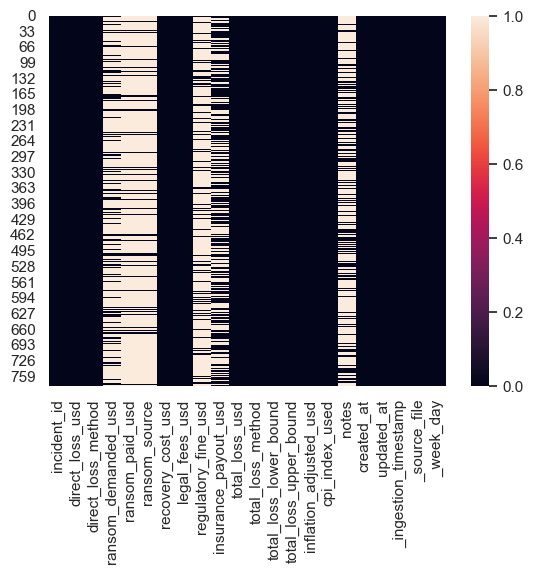

In [220]:
sns.heatmap(financial_impact_bronze.isnull())

In [221]:
print(financial_impact_bronze.duplicated(subset=['incident_id']).value_counts(),financial_impact_bronze.duplicated().sum())

False    778
Name: count, dtype: int64 0


In [222]:
financial_impact_bronze.dtypes

incident_id                          str
direct_loss_usd                  float64
direct_loss_method                   str
ransom_demanded_usd              float64
ransom_paid_usd                  float64
ransom_source                        str
recovery_cost_usd                float64
legal_fees_usd                   float64
regulatory_fine_usd              float64
insurance_payout_usd             float64
total_loss_usd                   float64
total_loss_method                    str
total_loss_lower_bound           float64
total_loss_upper_bound           float64
inflation_adjusted_usd           float64
cpi_index_used                       str
notes                                str
created_at                           str
updated_at                           str
_ingestion_timestamp      datetime64[us]
_source_file                         str
_week_day                            str
dtype: object

In [223]:
def transformar_para_prata(df_bronze):
    df = df_bronze.copy()
    df = df.drop_duplicates(subset=['incident_id'], keep='last')
    df.columns = df.columns.str.strip().str.lower()
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['updated_at'] = pd.to_datetime(df['updated_at'])
    return df

In [224]:
financial_impact_prata = transformar_para_prata(financial_impact_bronze)

In [225]:
financial_impact_prata.head(3)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at,_ingestion_timestamp,_source_file,_week_day
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,...,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-04 00:58:26.305104,financial_impact.csv,Saturday
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,...,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-04 00:58:26.307904,financial_impact.csv,Saturday
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,...,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-04 00:58:26.309756,financial_impact.csv,Saturday


In [226]:
financial_impact_prata.dtypes

incident_id                               str
direct_loss_usd                       float64
direct_loss_method                        str
ransom_demanded_usd                   float64
ransom_paid_usd                       float64
ransom_source                             str
recovery_cost_usd                     float64
legal_fees_usd                        float64
regulatory_fine_usd                   float64
insurance_payout_usd                  float64
total_loss_usd                        float64
total_loss_method                         str
total_loss_lower_bound                float64
total_loss_upper_bound                float64
inflation_adjusted_usd                float64
cpi_index_used                            str
notes                                     str
created_at                datetime64[us, UTC]
updated_at                datetime64[us, UTC]
_ingestion_timestamp           datetime64[us]
_source_file                              str
_week_day                         

In [227]:
colunas_financeiras = [
        'direct_loss_usd', 'ransom_demanded_usd', 'ransom_paid_usd', 
        'recovery_cost_usd', 'legal_fees_usd', 'regulatory_fine_usd', 
        'insurance_payout_usd', 'total_loss_usd', 'total_loss_lower_bound', 
        'total_loss_upper_bound', 'inflation_adjusted_usd'
    ]
for col in colunas_financeiras:
    if col in financial_impact_prata.columns:
        financial_impact_prata[col] = financial_impact_prata[col].fillna(0.0)

In [228]:
colunas_categoricas = ['direct_loss_method', 'ransom_source', 'total_loss_method', 'cpi_index_used']
for col in colunas_categoricas:
    if col in financial_impact_prata.columns:
        financial_impact_prata[col] = financial_impact_prata[col].fillna('desconhecido').str.strip().str.lower()

In [229]:
if 'notes' in financial_impact_prata.columns:
        financial_impact_prata['notes'] = financial_impact_prata['notes'].fillna('')

In [230]:
if 'ransom_paid_usd' in financial_impact_prata.columns:
        financial_impact_prata['label_resgate_pago'] = np.where(financial_impact_prata['ransom_paid_usd'] > 0, 1, 0)

In [231]:
colunas_leakage = [
        'ransom_paid_usd',       # Revela diretamente o target
        'total_loss_usd',        # Calculado no pós-incidente
       'total_loss_lower_bound',# Calculado no pós-incidente
        'total_loss_upper_bound',# Calculado no pós-incidente
        'inflation_adjusted_usd',# Calculado no pós-incidente
        'insurance_payout_usd',  # Resolvido muito depois do ataque
        'recovery_cost_usd',     # Somado após a contenção
        'notes'                  # Pode conter revelações sobre o desfecho
    ]
financial_impact_prata_ready = financial_impact_prata.drop(columns=[col for col in colunas_leakage if col in financial_impact_prata.columns])

In [232]:
if Path("Dados/prata/financial_impact_prata.parquet").exists() :
    os.remove('Dados/prata/financial_impact_prata.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)

financial_impact_prata.to_parquet('financial_impact_prata.parquet', compression='snappy')

if Path("Dados/prata").exists():
    if not (Path("Dados/prata/financial_impact_prata.parquet").exists()) :
        financial_impact_prata.to_parquet('financial_impact_prata.parquet', compression='snappy')
        shutil.move('financial_impact_prata.parquet','Dados/prata')

C:\Users\dudup\AppData\Local\Temp\ipykernel_14960\1623257724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_resgate_pago', data=financial_impact_prata, palette='Set2')


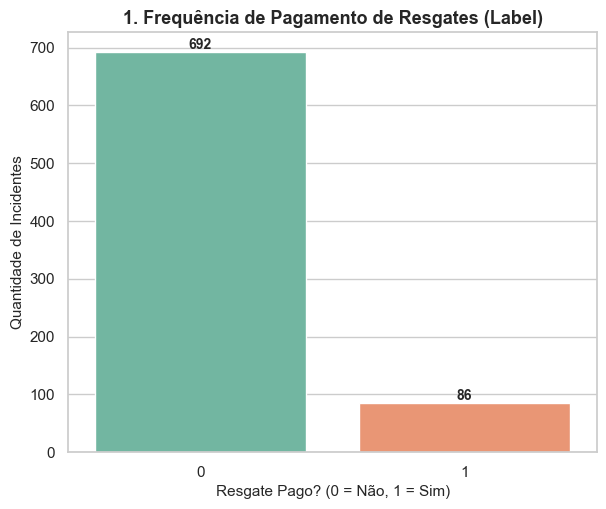

In [233]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_resgate_pago', data=financial_impact_prata, palette='Set2')
plt.title('1. Frequência de Pagamento de Resgates (Label)', fontsize=13, fontweight='bold')
plt.xlabel('Resgate Pago? (0 = Não, 1 = Sim)', fontsize=11)
plt.ylabel('Quantidade de Incidentes', fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

Frequência de Pagamento: Serve para mapear o desbalanceamento das classes. Se houver muitos zeros (não pago) e poucos uns (pago), o grupo deve citar que o modelo de ML precisará de técnicas de balanceamento (como SMOTE ou pesos de classe).

Text(0, 0.5, 'Valor Pago (USD)')

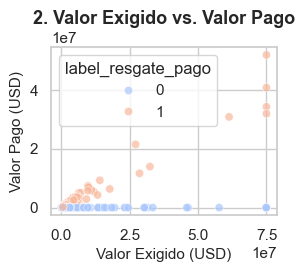

In [234]:
plt.subplot(2, 2, 2)
# Filtrando apenas onde houve exigência para não gerar gráficos zerados
com_demanda = financial_impact_prata[financial_impact_prata['ransom_demanded_usd'] > 0]

sns.scatterplot(x='ransom_demanded_usd', y='ransom_paid_usd', 
                hue='label_resgate_pago', alpha=0.7, palette='coolwarm',
                data=com_demanda)
plt.title('2. Valor Exigido vs. Valor Pago', fontsize=13, fontweight='bold')
plt.xlabel('Valor Exigido (USD)', fontsize=11)
plt.ylabel('Valor Pago (USD)', fontsize=11)

Valor Exigido vs. Pago: Um gráfico de dispersão perfeito para enxergar se as empresas costumam ceder ao valor total pedido pelos cibercriminosos ou se há uma margem frequente de barganha/redução.

C:\Users\dudup\AppData\Local\Temp\ipykernel_14960\1811721790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='direct_loss_method', y='direct_loss_usd', data=metodos_reais, palette='Set3')


([0, 1, 2],
 [Text(0, 0, 'disclosed'), Text(1, 0, 'calculated'), Text(2, 0, 'estimated')])

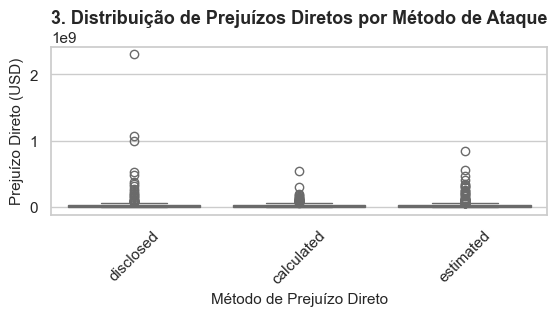

In [235]:
plt.subplot(2, 1, 2)
# Filtrando o 'desconhecido' para focar nos métodos reais catalogados
metodos_reais = financial_impact_prata[financial_impact_prata['direct_loss_method'] != 'desconhecido']

sns.boxplot(x='direct_loss_method', y='direct_loss_usd', data=metodos_reais, palette='Set3')
plt.title('3. Distribuição de Prejuízos Diretos por Método de Ataque', fontsize=13, fontweight='bold')
plt.xlabel('Método de Prejuízo Direto', fontsize=11)
plt.ylabel('Prejuízo Direto (USD)', fontsize=11)
plt.xticks(rotation=45)

Prejuízos por Método: O boxplot ajuda a rastrear a assimetria e a presença de outliers (ataques extremamente caros). Isso responde perfeitamente à busca por "padrões" exigida no enunciado.

# Relatório Técnico: Pipeline de Dados para Machine Learning (Camadas Bronze e Prata)

Este relatório documenta o processo de extração, tratamento, auditoria e preparação dos dados de impacto financeiro de incidentes cibernéticos. O objetivo principal deste projeto foi construir um pipeline robusto que garanta a qualidade dos dados e evite o vazamento de informações (*data leakage*) para futuros modelos de Machine Learning.

---

## 1. Arquitetura e Linhagem dos Dados (Data Lineage)

O fluxo de dados foi projetado seguindo a arquitetura de medalhão simplificada, garantindo rastreabilidade e integridade:

1. **Origem**: Arquivo bruto no formato CSV (`financial_impact.csv`).
2. **Camada Bronze**: Os dados foram lidos e enriquecidos com metadados de auditoria (data de ingestão, arquivo de origem e dia da semana). Os dados foram persistidos no formato colunar comprimido `Parquet`.
3. **Camada Prata**: Leitura da camada Bronze, aplicação de regras de limpeza, padronização de strings, tipagem de dados, tratamento rigoroso de valores nulos e criação da variável alvo (*Label*).
4. **Camada Prata Pronta para ML**: Um subset da camada prata foi gerado removendo-se todas as variáveis que representam informações de pós-incidente, mitigando riscos de *Data Leakage*.

---

## 2. Relatório de Qualidade de Dados (Camada Bronze)

Na análise inicial da camada Bronze, foram identificadas as seguintes inconformidades:

* **Valores Nulos**: Alta concentração de nulos em colunas financeiras (como custos de recuperação e multas regulatórias) e em colunas categóricas (como método de perda direta).
* **Tipagem**: Colunas de data (`created_at` e `updated_at`) estavam mapeadas como texto (*string*), impedindo operações cronológicas diretas.
* **Formatos de Texto**: Inconsistências de capitalização e espaços em branco nas variáveis categóricas.

---

## 3. Transformações Aplicadas na Camada Prata

Para garantir que os dados estejam prontos para o consumo de algoritmos de Machine Learning, as seguintes transformações e regras automáticas de validação foram aplicadas:

| Operação | Regra Aplicada | Justificativa |
| :--- | :--- | :--- |
| **Deduplicação** | `drop_duplicates(subset=['incident_id'])` | Garantir a unicidade de cada incidente no dataset. |
| **Padronização de Nomes** | Caixa baixa e substituição de espaços por `_` | Facilitar a escrita de consultas e evitar quebras de código por caracteres especiais. |
| **Tratamento de Nulos (Financeiro)** | Preenchimento com `0.0` | Assumir a ausência de valor financeiro (ex: se o resgate pago está nulo, considera-se que não houve pagamento). |
| **Tratamento de Nulos (Texto)** | Preenchimento com `'desconhecido'` | Evita que registros úteis sejam descartados e mantém a integridade da classe preditiva. |
| **Conversão de Datas** | Transformado para o tipo `datetime64` | Permitir a posterior engenharia de recursos temporais (ex: tempo de resposta do incidente). |

---

## 4. Engenharia de Recursos e Definição do Label

Para alimentar o modelo de Machine Learning, foi criada a seguinte variável alvo (*Label*):

* **`label_resgate_pago`**: Variável binária onde `1` indica que a empresa realizou o pagamento do resgate (`ransom_paid_usd` > 0) e `0` indica que não houve pagamento.

---

## 5. Tabela de Checklist Anti-Leakage

O vazamento de dados (*Data Leakage*) ocorre quando variáveis que só seriam conhecidas **após** o desfecho do evento são inseridas no modelo de treinamento. Para evitar que o modelo aprenda com o "futuro", as seguintes colunas foram removidas do dataset de treinamento:

| Coluna Removida | Motivo da Remoção / Risco de Leakage |
| :--- | :--- |
| `ransom_paid_usd` | Revela diretamente o resultado do alvo (*Label*). |
| `total_loss_usd` | Valor calculado e consolidado apenas após o encerramento total do incidente. |
| `total_loss_lower_bound` | Métrica analítica de pós-incidente. |
| `total_loss_upper_bound` | Métrica analítica de pós-incidente. |
| `inflation_adjusted_usd` | Calculado a posteriori. |
| `insurance_payout_usd` | O pagamento do seguro geralmente leva meses após o ataque para ser deferido. |
| `recovery_cost_usd` | Custo somado gradativamente após a contenção do ataque. |
| `notes` | Textos descritivos que costumam conter revelações diretas sobre o desfecho da negociação. |

---

## 6. Análise Exploratória de Dados (Visualizações)

Como solicitado nas diretrizes do projeto, foram geradas 3 visualizações para identificação de padrões sobre a base tratada na Camada Prata:

1. **Distribuição do Label de Pagamento**: Revelou a proporção de empresas que cedem à extorsão contra as que resistem. Essencial para planejar estratégias de balanceamento de classes no modelo.
2. **Dispersão de Valor Exigido vs. Valor Pago**: Demonstrou visualmente a dinâmica de negociação dos cibercriminosos, indicando se os valores pagos costumam ser menores do que os inicialmente exigidos.
3. **Boxplot de Prejuízos por Método de Ataque**: Permitiu identificar quais vias de ataque causam maior impacto financeiro direto e o volume de *outliers* (ataques com prejuízos extremos).